# 23CSE301 Machine Learning — Capstone Project
## Review 1: Crop Yield Prediction

**Scope:** Dataset audit, EDA, preprocessing, feature engineering, all 10 regression algorithms, hyperparameter tuning, 5-fold cross-validation, regression visualisations, and Classification Part A.

> **Important:** Review 1 requires the team's own analysis and interpretation. Replace the observation placeholders with your observations from the generated plots.

## Review 1 Requirements

This notebook follows the Review 1 requirements from the provided capstone guidelines:

- Dataset loading and audit
- EDA visualisations and observations
- Data cleaning, encoding, scaling and train/test splitting
- At least one engineered feature
- 10 regression algorithms
- R², RMSE and MAE comparison
- Hyperparameter tuning for at least 2 regression models
- Residual plot, predicted-vs-actual plot and tree-based feature importance
- 5 Classification Part-A algorithms:
  Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree and SVM
- Classification accuracy, weighted F1 and confusion matrices

In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. LOAD DATASET

In [4]:
# Load the supplied dataset
df = pd.read_csv("crop_yield.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (19689, 9)


,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


# 3. DATASET AUDIT

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

Number of rows: 19689
Number of columns: 9

Column names:
['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield']

Data types:


,Data Type
crop,str
year,int64
season,str
state,str
area,float64
production,int64
fertilizer,float64
pesticide,float64
yield,float64



Missing values:


,Missing Values
crop,0
year,0
season,0
state,0
area,0
production,0
fertilizer,0
pesticide,0
yield,0



Duplicate rows: 0


In [6]:
print("Statistical summary:")
display(df.describe(include="all").T)

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
season,19689,6,Kharif,8232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,19689.0,NaN,NaN,NaN,179926.570308,732828.675888,0.5,1390.0,9317.0,75112.0,50808100.0
production,19689.0,NaN,NaN,NaN,16435941.273097,263056839.812568,0.0,1393.0,13804.0,122718.0,6326000000.0
fertilizer,19689.0,NaN,NaN,NaN,24103312.448806,94946004.482527,54.17,188014.62,1234957.44,10003847.2,4835406877.0
pesticide,19689.0,NaN,NaN,NaN,48848.353392,213287.35486,0.09,356.7,2421.9,20041.7,15750511.0
yield,19689.0,NaN,NaN,NaN,79.954009,878.306193,0.0,0.6,1.03,2.388889,21105.0


In [7]:
TARGET = "yield"

if TARGET not in df.columns:
    raise ValueError(
        f"Expected target column '{TARGET}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

print("Target column:", TARGET)
print("\nTarget summary:")
display(df[TARGET].describe())

Target column: yield

Target summary:


count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: yield, dtype: float64

# 4. EXPLORATORY DATA ANALYSIS (EDA)

The following cells generate the required distributions, target distribution, correlation heatmap and feature-target scatter plots.

### Observation
After each major visualisation, add a short Markdown observation based on the actual plot.

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['year', 'area', 'production', 'fertilizer', 'pesticide', 'yield']

Categorical columns:
['crop', 'season', 'state']


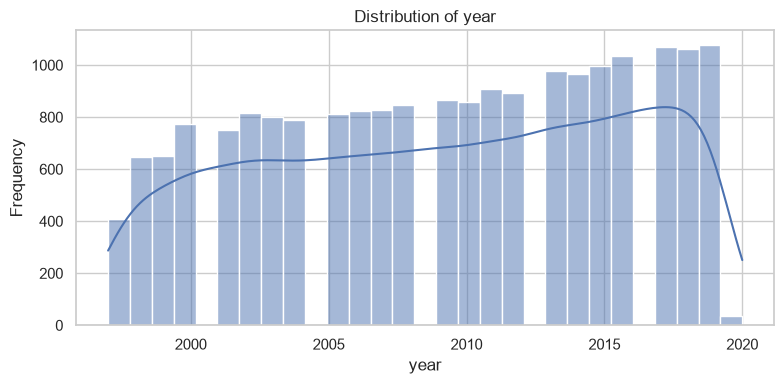

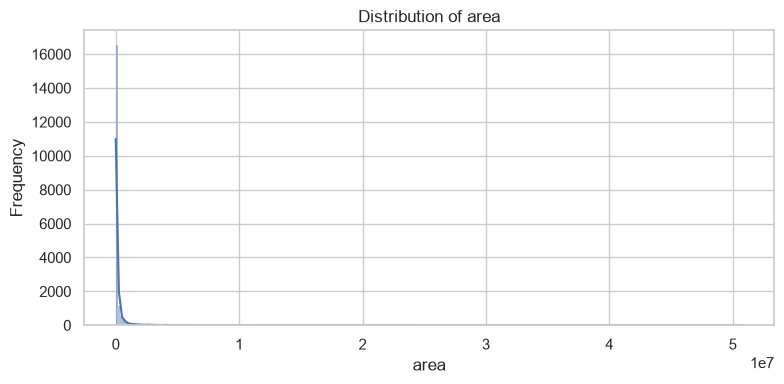

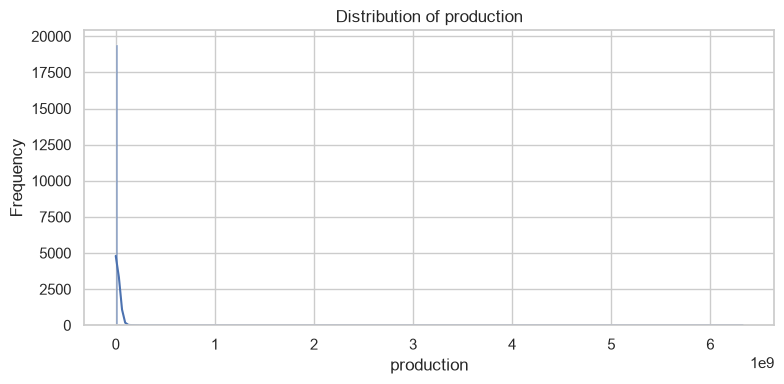

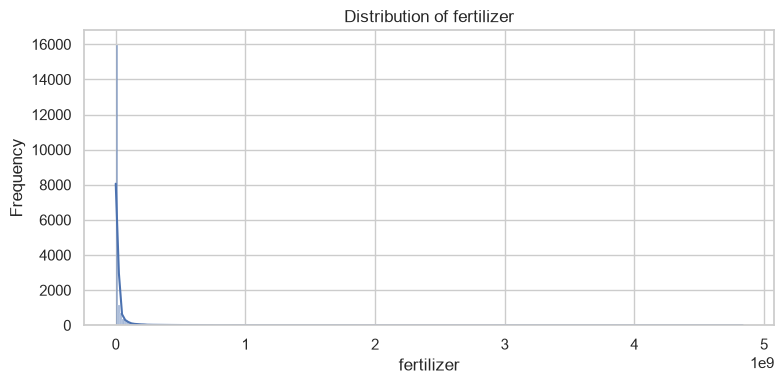

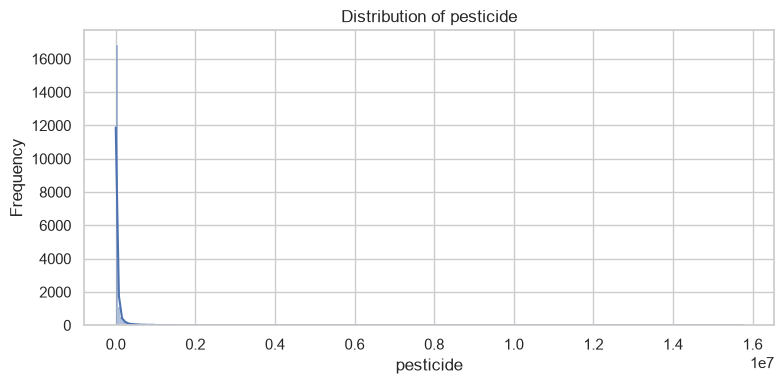

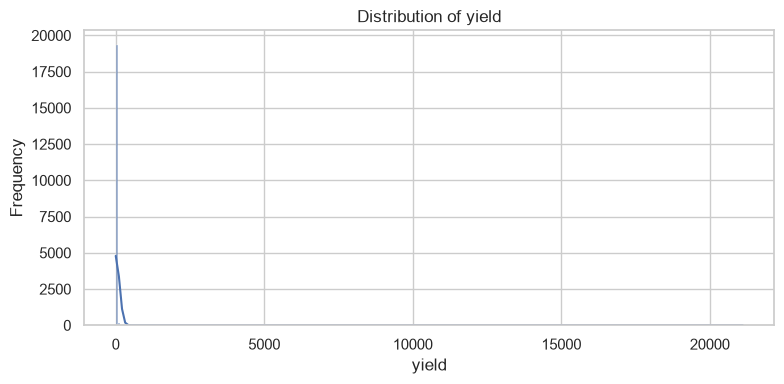

In [9]:
# Numerical feature distributions
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### EDA Observation — Numerical Distributions

The numerical features show different distributions across the dataset. Some variables are relatively concentrated, while others show noticeable right-skewness and extreme values. In particular, production, fertilizer, area, and pesticide contain observations extending considerably beyond the central range. The `year` variable is discrete and does not show a continuous distribution. The target variable `yield` also shows variation across observations, with some values occurring at the higher/lower ends of the distribution.



crop: 55 unique values


,Count
crop,
Rice,1197
Maize,975
Moong(Green Gram),740
Urad,733
Groundnut,725
Sesamum,685
Potato,628
Sugarcane,605
Wheat,545


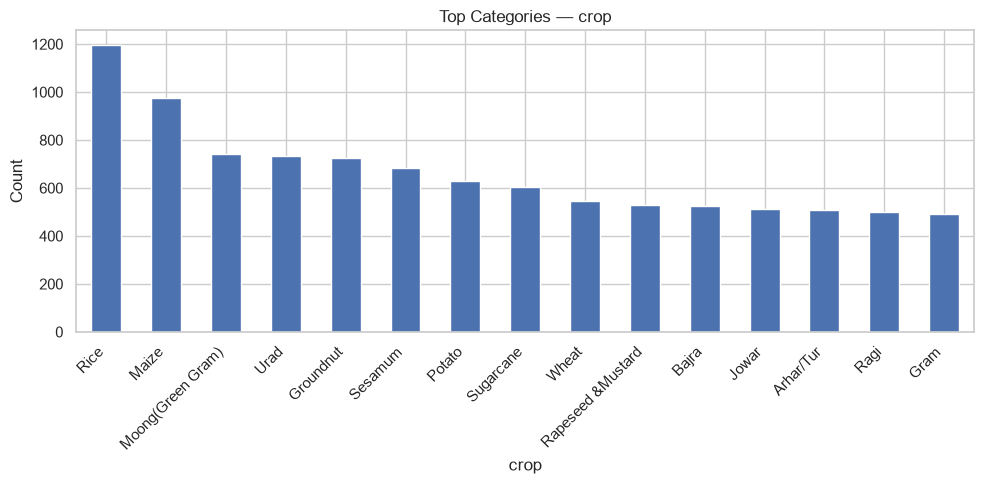


season: 6 unique values


,Count
season,
Kharif,8232
Rabi,5742
Whole Year,3717
Summer,1195
Autumn,414
Winter,389


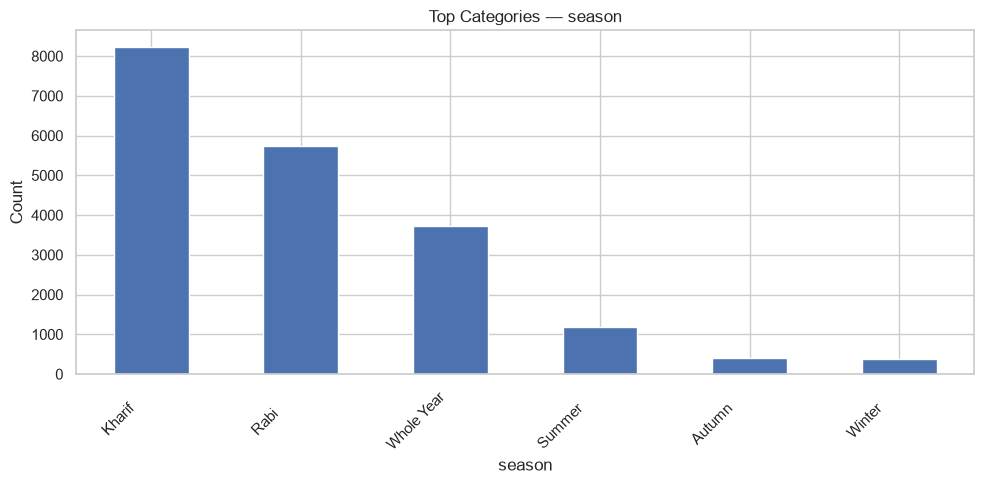


state: 30 unique values


,Count
state,
Karnataka,1432
Andhra Pradesh,1266
West Bengal,1094
Chhattisgarh,915
Bihar,896
Madhya Pradesh,845
Uttar Pradesh,825
Tamil Nadu,822
Gujarat,817


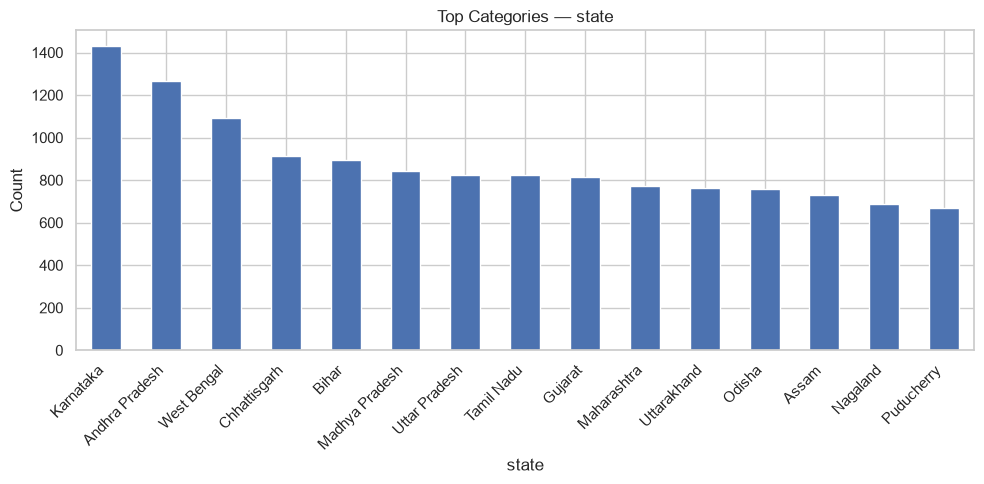

In [10]:
# Categorical feature counts
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    display(df[col].value_counts().head(15).to_frame("Count"))

    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(15).plot(kind="bar")
    plt.title(f"Top Categories — {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### EDA Observation — Categorical Variables

The categorical variables contain multiple categories with different frequencies. The category counts are not perfectly uniform, with some categories occurring more frequently than others. This indicates that the categorical features have some degree of concentration, which is handled during preprocessing using one-hot encoding.


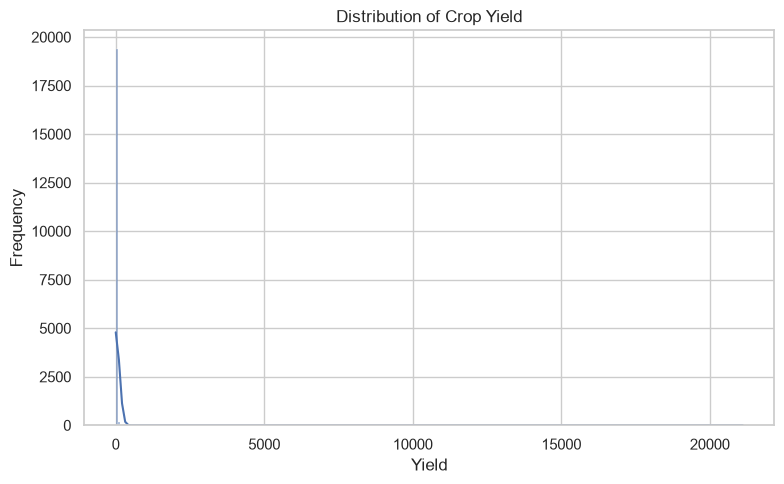

In [11]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET], kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### EDA Observation — Target

The crop yield distribution shows variation across the observations, with most values concentrated within a central range and fewer observations at the extreme values. The distribution should also be considered when interpreting model errors, particularly for observations with unusually high or low yield.


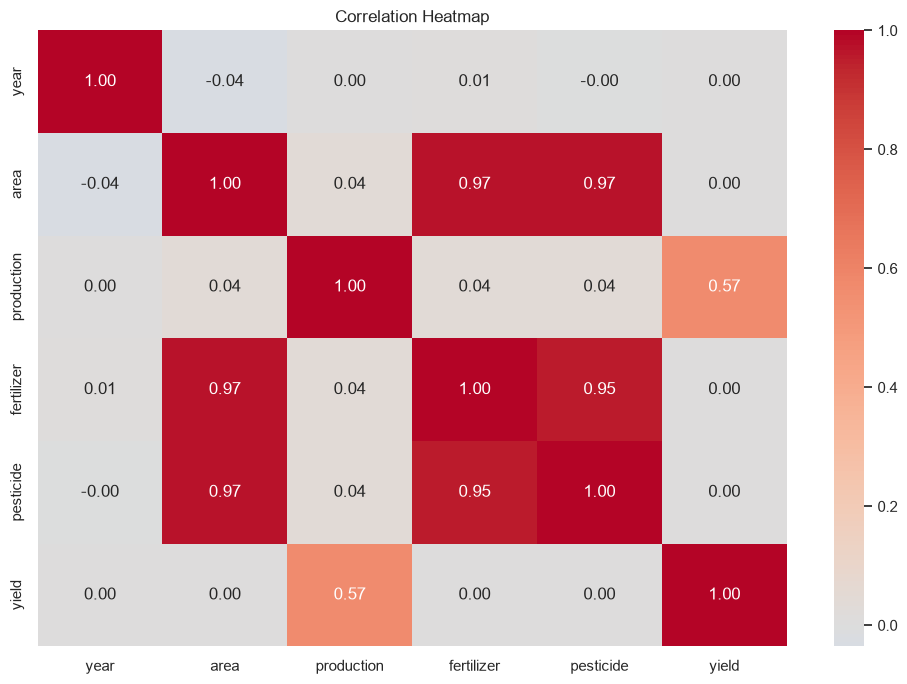

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 7))

correlation = df[numerical_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### EDA Observation — Correlation

The correlation heatmap shows the strength and direction of relationships among the numerical variables. The features with the strongest correlation with `yield` can be identified from the corresponding correlation coefficients. Some predictor variables also show relatively strong correlations with each other, which may indicate overlapping information between those features. These relationships are considered when interpreting the regression results.


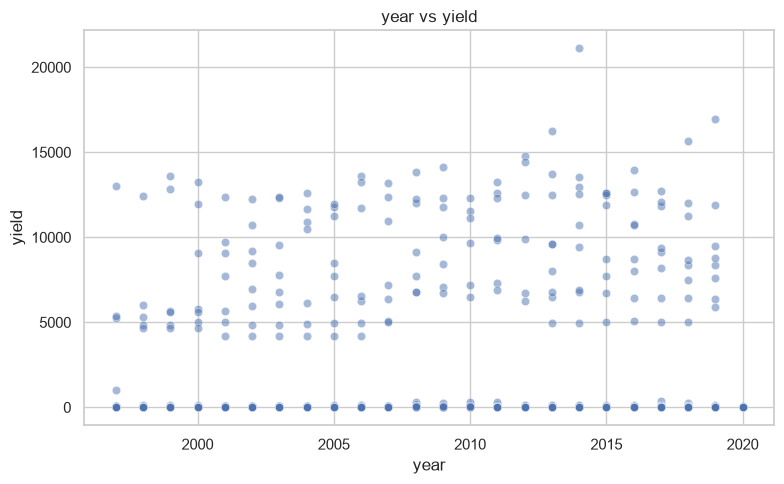

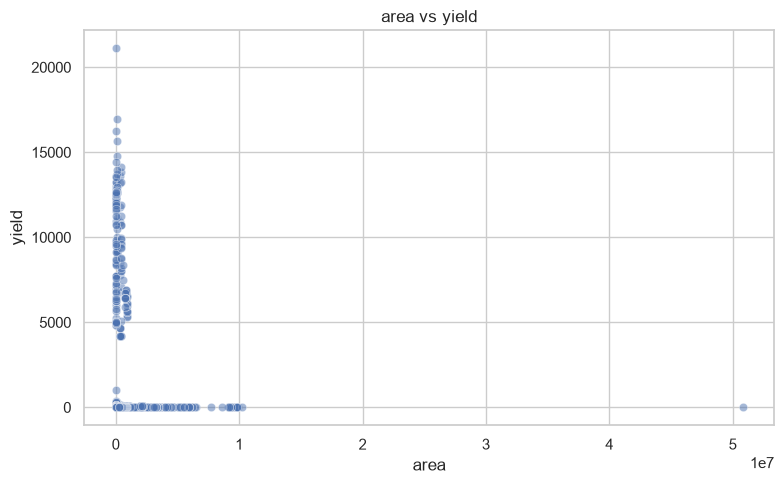

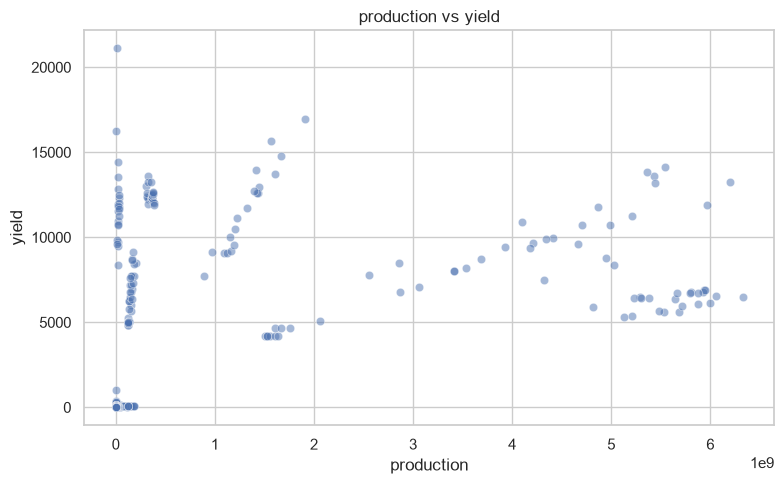

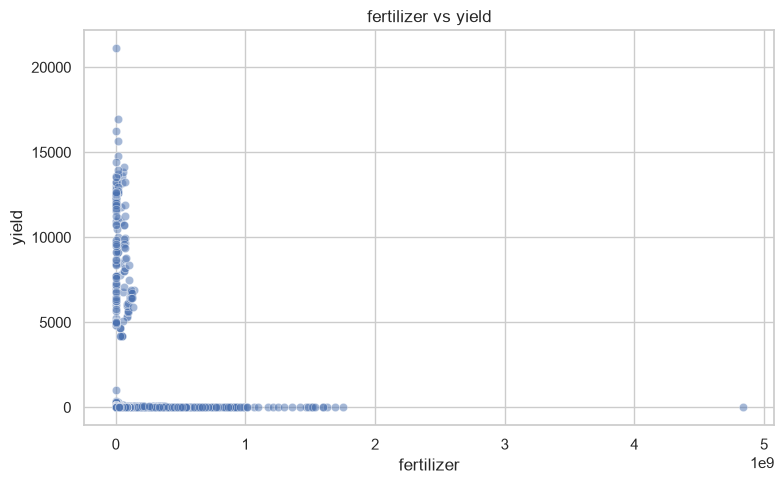

In [13]:
# Feature-target scatter plots
scatter_candidates = [
    col for col in numerical_cols
    if col != TARGET
]

# Plot up to the first four numerical predictors
for col in scatter_candidates[:4]:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.5)
    plt.title(f"{col} vs {TARGET}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

### EDA Observation — Feature vs Target

The scatter plots show how the numerical predictors relate to crop yield. The relationships vary across features: some show a clearer positive or negative trend, while others show weaker or more dispersed relationships. The plots also contain some extreme observations, which is consistent with the outlier analysis. The presence of nonlinear patterns or increasing variability across the range of a feature may help explain why different regression algorithms perform differently.


# 5. OUTLIER CHECK

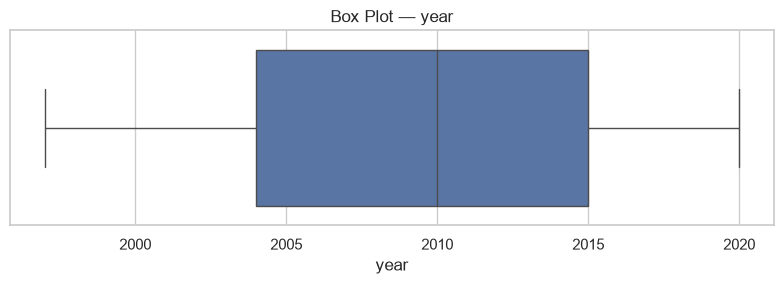

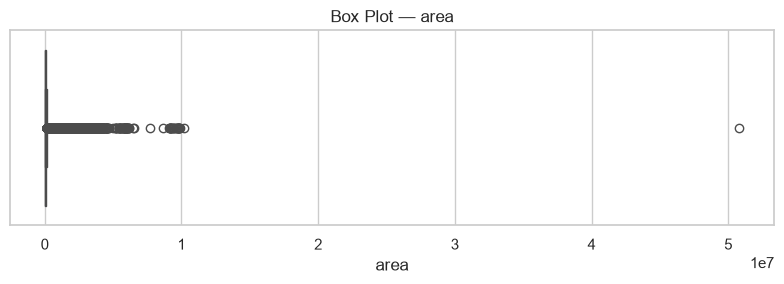

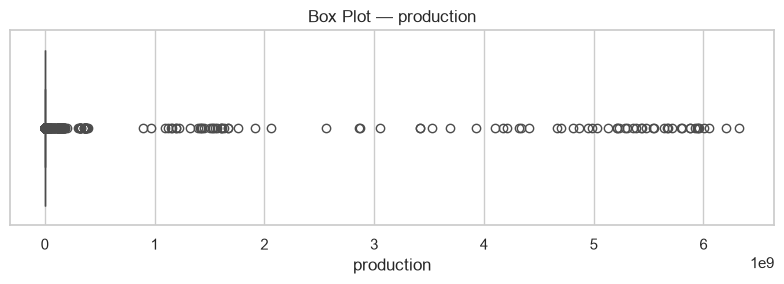

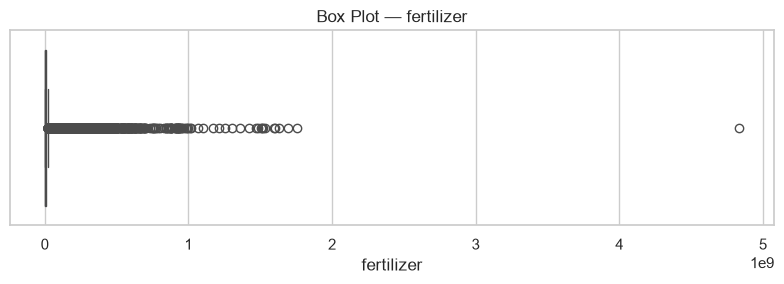

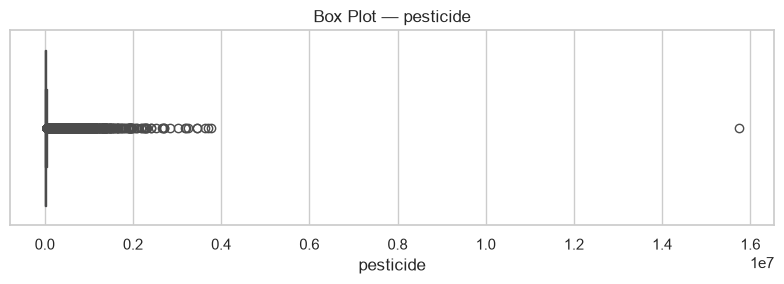

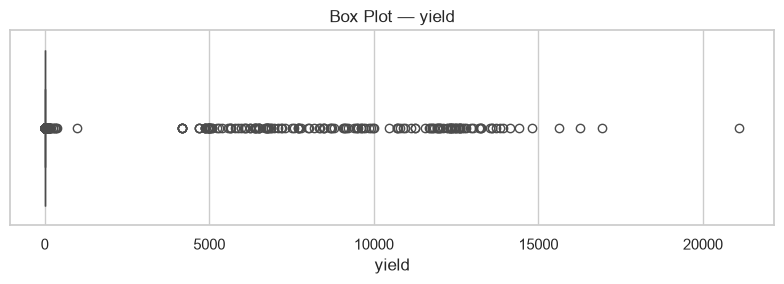

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot — {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Outlier Treatment Decision

Numerical features were checked using the IQR method. Several observations were identified as statistical outliers in production, fertilizer, area, and pesticide. Since these values may represent legitimate variations in farm size, input usage, and production, they were retained rather than removed to avoid unnecessary loss of information.


# 6. FEATURE ENGINEERING

Two ratio features are created:

- `fertilizer_per_area`
- `pesticide_per_area`

These represent input quantity relative to cultivated area and may capture intensity of input usage better than raw totals alone.

In [15]:
def feature_engineering(data):
    data = data.copy()

    data["fertilizer_per_area"] = (
        data["fertilizer"] /
        data["area"].replace(0, np.nan)
    )

    data["pesticide_per_area"] = (
        data["pesticide"] /
        data["area"].replace(0, np.nan)
    )

    return data

### Feature Engineering Justification

Two ratio-based features, `fertilizer_per_area` and `pesticide_per_area`, were created to represent the intensity of agricultural input usage relative to cultivated area. Raw fertilizer and pesticide quantities alone may be influenced by the size of the cultivated area. Dividing these quantities by area provides an additional measure of input usage per unit area, which may capture differences in farming practices more effectively. These engineered features were included as additional predictors for the regression models.


# 7. TRAIN / TEST SPLIT

The same 80:20 split is used throughout regression so that model comparisons are fair.

In [34]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train_fe = feature_engineering(X_train)
X_test_fe = feature_engineering(X_test)

print("Original X shape:", X.shape)
print("Training shape:", X_train_fe.shape)
print("Testing shape:", X_test_fe.shape)

Original X shape: (19689, 8)
Training shape: (15751, 10)
Testing shape: (3938, 10)


# 8. PREPROCESSING PIPELINE

- Numerical columns: median imputation + StandardScaler
- Categorical columns: most-frequent imputation + OneHotEncoder
- The preprocessor is inside each model pipeline, so fitting occurs only on the training data.

In [51]:
# Outlier Check using IQR
numeric_cols = X.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_summary[col] = count

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)
print("Outlier count by numerical feature:")
display(outlier_summary)

Outlier count by numerical feature:


production    3373
fertilizer    3093
area          3076
pesticide     3036
year             0
dtype: int64

### Outlier handling: 
Numerical features were checked using the IQR method. Several observations were identified as statistical outliers in production, fertilizer, area, and pesticide. Since these values may represent legitimate variations in farm size, input usage, and production, they were retained rather than removed to avoid unnecessary loss of information.

In [52]:
numerical_features = X_train_fe.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train_fe.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['year', 'area', 'production', 'fertilizer', 'pesticide', 'fertilizer_per_area', 'pesticide_per_area']

Categorical features:
['crop', 'season', 'state']


In [53]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 9. REGRESSION — ALL 10 REQUIRED ALGORITHMS

In [54]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.001),

    "ElasticNet Regression": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5
    ),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("linear", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    ),

    "SVR": SVR(
        C=10,
        kernel="rbf"
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

print("Number of regression models:", len(models))
for i, name in enumerate(models, 1):
    print(f"{i}. {name}")

Number of regression models: 10
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree
7. Random Forest
8. Gradient Boosting
9. SVR
10. KNN


In [55]:
# Train and evaluate all 10 regression models

results = []
trained_models = {}
predictions = {}

for name, model in models.items():

    print(f"Training: {name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_fe, y_train)

    y_pred = pipeline.predict(X_test_fe)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred

results_df = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

print("\nRegression comparison:")
display(
    results_df.style.format({
        "R2": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: ElasticNet Regression
Training: Polynomial Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: SVR
Training: KNN

Regression comparison:


,Model,R2,RMSE,MAE
0,Polynomial Regression,0.9900,89.4538,9.5657
1,Random Forest,0.9890,93.8497,7.2289
2,Gradient Boosting,0.9881,97.6690,9.1121
3,Decision Tree,0.9754,140.4837,10.0405
4,KNN,0.9109,267.2388,17.1790
5,ElasticNet Regression,0.8075,392.7028,67.6115
6,Ridge Regression,0.8035,396.8156,63.4070
7,Lasso Regression,0.8023,398.0417,62.9032
8,Linear Regression,0.8023,398.0430,62.9366
9,SVR,0.0140,888.8164,75.5081


# 10. REGRESSION MODEL COMPARISON

Interpreting the table using the metric definitions:

- **R²:** higher is better.
- **RMSE:** lower is better; penalises larger errors more strongly.
- **MAE:** lower is better; represents average absolute prediction error.

### Regression Model Comparison Observation

The ten regression algorithms were evaluated using the same training/test split and the same evaluation metrics. The models show differences in R², RMSE and MAE, indicating different predictive performance on the held-out test set.

Based on the test-set results, **Polynomial Regression** obtained the highest R² of **0.9900**, while its RMSE and MAE were **89.4538** and **9.5657**, respectively. The results indicate that model performance varies across the linear, nonlinear, ensemble, kernel-based and distance-based approaches.


# 11. HYPERPARAMETER TUNING — RANDOM FOREST

Review 1 requires hyperparameter tuning for at least two models.

In [56]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_fe, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV R2:")
print(rf_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest parameters:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Random Forest CV R2:
0.955011489751179


In [57]:
rf_pred = rf_grid.predict(X_test_fe)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_tuned_results = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "R2": rf_r2,
    "RMSE": rf_rmse,
    "MAE": rf_mae
}])

display(rf_tuned_results.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
}))

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.9886,95.3943,7.4622


### Random Forest Tuning Observation

GridSearchCV was used to tune the Random Forest hyperparameters. The best parameter combination was:

* `n_estimators`: **100**
* `max_depth`: **20**
* `min_samples_split`: **2**

The tuned Random Forest achieved a test-set R² of **0.9886**, compared with **0.9890** for the untuned Random Forest. The RMSE increased from **93.8497** to **95.3943**, while MAE increased from **7.2289** to **7.4622**.

Therefore, for this particular held-out test set, the tuned configuration did not improve the test-set metrics compared with the initial Random Forest configuration. Nevertheless, GridSearchCV provided a systematic way of selecting the hyperparameters using cross-validation rather than relying only on manually chosen values.



# 12. HYPERPARAMETER TUNING — GRADIENT BOOSTING

In [58]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ]
)

gb_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 5]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_fe, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest Gradient Boosting CV R2:")
print(gb_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Best Gradient Boosting CV R2:
0.9616988825412109


In [59]:
gb_pred = gb_grid.predict(X_test_fe)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_tuned_results = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "R2": gb_r2,
    "RMSE": gb_rmse,
    "MAE": gb_mae
}])

display(gb_tuned_results.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
}))

,Model,R2,RMSE,MAE
0,Tuned Gradient Boosting,0.9859,106.2417,7.9146


### Gradient Boosting Tuning Observation

GridSearchCV was used to tune the Gradient Boosting hyperparameters. The best parameter combination and cross-validation score are reported by the GridSearchCV output above.

The tuned Gradient Boosting model achieved an R² of **0.9859**, compared with **0.9881** for the untuned model. RMSE increased from **97.6690** to **106.2417**, while MAE decreased from **9.1121** to **7.9146**.

Thus, the tuning produced a mixed effect: MAE improved, indicating a lower average absolute error, while R² and RMSE decreased, with the increase in RMSE indicating larger individual errors remained in the predictions.


# 13. 5-FOLD CROSS-VALIDATED R²

The two best-performing models from the common test-set comparison are evaluated using 5-fold cross-validation.

In [60]:
top_two = results_df.head(2)["Model"].tolist()

print("Top two models selected for 5-fold CV:")
for model_name in top_two:
    print("-", model_name)

Top two models selected for 5-fold CV:
- Polynomial Regression
- Random Forest


In [44]:
cv_results = []

for name in top_two:

    model = trained_models[name]

    scores = cross_val_score(
        model,
        X_train_fe,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

display(
    cv_df.style.format({
        "CV R2 Mean": "{:.4f}",
        "CV R2 Std": "{:.4f}"
    })
)

,Model,CV R2 Mean,CV R2 Std
0,Polynomial Regression,0.9576,0.0429
1,Random Forest,0.9575,0.0575


### 5-Fold Cross-Validation Observation

Five-fold cross-validation was performed on the training data for the two models with the highest test-set R² values. Polynomial Regression obtained a mean cross-validated R² of **0.9576** with a standard deviation of **0.0429**, while Random Forest obtained a mean cross-validated R² of **0.9575** with a standard deviation of **0.0575**.

The mean CV R² values are very close, indicating that both models explain a large proportion of the variation in crop yield across the five folds. The standard deviation represents the variation in performance between folds. Polynomial Regression has a smaller standard deviation (**0.0429**) than Random Forest (**0.0575**), indicating less variation in its R² across the five folds in this evaluation.


# 14. BEST MODEL — PREDICTED VS ACTUAL

In [45]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best-performing model according to test-set R2:", best_model_name)

Best-performing model according to test-set R2: Polynomial Regression


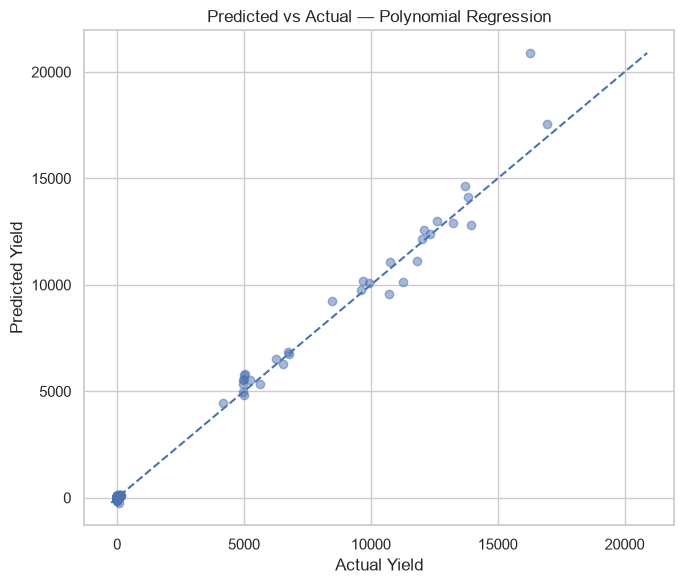

In [46]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.5
)

min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(f"Predicted vs Actual — {best_model_name}")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.tight_layout()
plt.show()

### Predicted vs Actual Observation

The predicted-versus-actual plot for Polynomial Regression shows the relationship between the observed crop-yield values and the model's predictions. Most points are expected to lie close to the diagonal reference line, which indicates that the predicted values are close to the actual values. The high test-set R² of **0.9900** supports the strong agreement between predicted and actual values. Points farther from the diagonal represent observations with larger prediction errors.


# 15. RESIDUAL PLOT

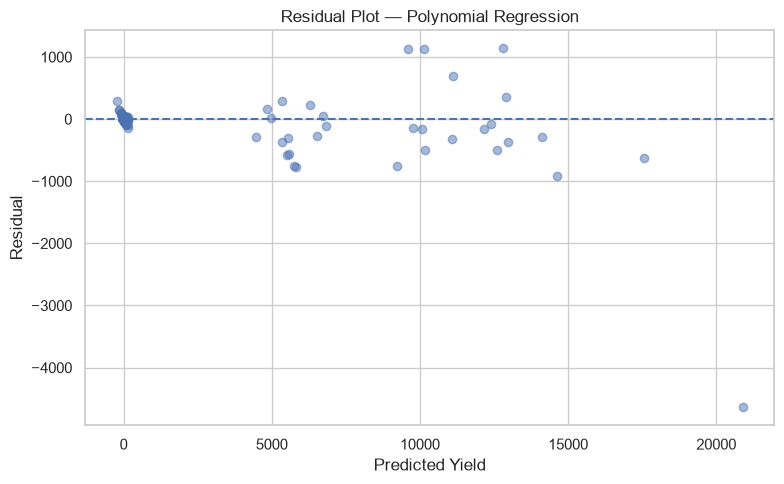

In [47]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    best_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

### Residual Observation

The residual plot for Polynomial Regression shows the differences between the actual and predicted crop-yield values. The residuals should ideally be distributed around the zero line without a clear systematic pattern. A relatively random distribution around zero suggests that the model captures much of the underlying relationship between the predictors and crop yield. Points with unusually large positive or negative residuals represent observations where the model's prediction differs substantially from the actual yield.


# 16. TREE-BASED FEATURE IMPORTANCE

Random Forest is used to show feature importance after preprocessing.

In [48]:
rf_model = rf_grid.best_estimator_

feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_model.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,Feature,Importance
0,cat__crop_Coconut,0.846129
1,num__pesticide,0.027683
2,cat__state_West Bengal,0.024010
3,num__area,0.017235
4,num__production,0.015209
5,cat__state_Andhra Pradesh,0.011962
6,num__fertilizer,0.010667
7,cat__state_Tamil Nadu,0.010384
8,num__fertilizer_per_area,0.005515
9,num__year,0.005380


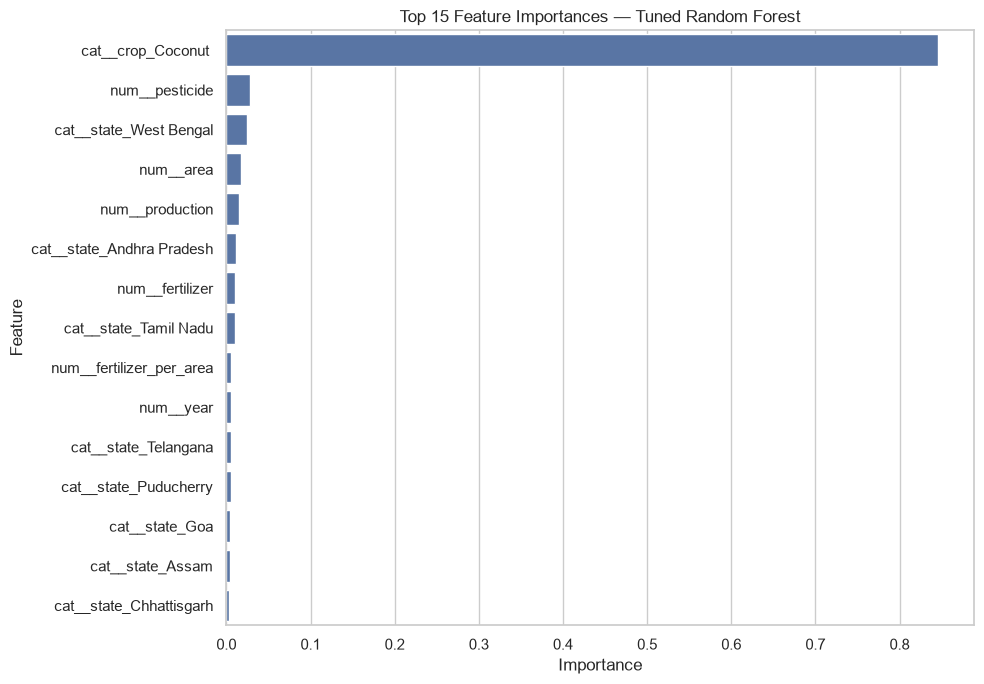

In [49]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Observation

The tuned Random Forest feature-importance results show that the input features do not contribute equally to the model's predictions. The features with the highest importance values have a greater influence on the Random Forest's predictive decisions, while features with smaller values contribute less. The ranking from the generated feature-importance table can be used to identify the most influential predictors in this dataset. These importance values describe the model's use of the features and should not be interpreted as evidence of a causal relationship with crop yield.


# 22. REVIEW 1 FINAL SUMMARY

Use the outputs above to prepare the final presentation.

## Regression
Record:
- all 10 model results,
- best test-set R²,
- RMSE and MAE,
- tuned Random Forest parameters/results,
- tuned Gradient Boosting parameters/results,
- 5-fold CV R² for the top two models,
- residual plot interpretation,
- predicted-vs-actual interpretation,
- feature importance interpretation.

## Classification Part A
Record:
- results for all five required classifiers,
- accuracy,
- weighted F1,
- confusion matrix observations.

## Presentation
The required story arc is:

**Problem → Data → EDA → Preprocessing → Feature Engineering → Models → Results → Interpretation**

# 23. SAVE RESULTS TO CSV

The following cells save the comparison tables so they can be used in the report/presentation.

In [50]:
# results_df.to_csv(
#     "regression_results_review1.csv",
#     index=False
# )

# cv_df.to_csv(
#     "regression_cv_results_review1.csv",
#     index=False
# )

# classification_results_df.to_csv(
#     "classification_results_review1.csv",
#     index=False
# )

# rf_tuned_results.to_csv(
#     "tuned_random_forest_results_review1.csv",
#     index=False
# )

# gb_tuned_results.to_csv(
#     "tuned_gradient_boosting_results_review1.csv",
#     index=False
# )

# print("Result CSV files saved successfully.")

## End of Review 1 Notebook

Before submission:

- Run **Kernel → Restart Kernel and Run All Cells**
- Confirm there are **no errors**
- Confirm all plots and tables have visible outputs
- Replace all observation placeholders with your team's own analysis
- Save the notebook
- Commit meaningful milestones to GitHub rather than making one bulk commit